In [1]:
!pip install sentence-transformers
from google.colab import files
uploaded_files = files.upload() # upload the local files from the computer

Saving data_preprocessed_csv.csv to data_preprocessed_csv.csv


In [2]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0,'/content') # looking in /content for any local files we uploaded

In [3]:
df = pd.read_csv('data_preprocessed_csv.csv')
df['cleaned_abstract'] = df['cleaned_abstract'].fillna('') # handling missing values
df['abstract'] = df['abstract'].fillna('')
print("Dataset dimensions :",df.shape)
print("Columns in dataset :",df.columns.values)
print("\nFirst 2 rows of the abstract column :")
print(df['abstract'].head())

Dataset dimensions : (27121, 14)
Columns in dataset : ['id' 'submitter' 'authors' 'title' 'comments' 'journal-ref' 'doi'
 'abstract' 'report-no' 'categories' 'versions' 'year' 'cleaned_abstract'
 'period']

First 2 rows of the abstract column :
0      This paper uncovers and explores the close r...
1      In these notes we formally describe the func...
2      Motivation: Profile hidden Markov Models (pH...
3      We introduce a framework for filtering featu...
4      This paper proposes an approach to training ...
Name: abstract, dtype: object


In [4]:
period_order = ['2007-2011','2012-2016','2017-2021'] #standardising the range to compare with others later

# Using MiniLM Model

In [5]:
from sentence_transformers import SentenceTransformer

In [6]:
model_used = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
# Extracts abstracts and encode them into numerical embeddings using the model
abstracts = df['abstract'].tolist()
embeddings = model_used.encode(abstracts,show_progress_bar=True)
print(f"Embeddings shape : {embeddings.shape}")

Batches:   0%|          | 0/848 [00:00<?, ?it/s]

Embeddings shape : (27121, 384)


In [8]:
np.save('embeddings_nithya.npy',embeddings) # save the embeddings to the computer
files.download('embeddings_nithya.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
def manual_cossim(ppr1,ppr2):
    return np.dot(ppr1,ppr2)/(np.linalg.norm(ppr1)*np.linalg.norm(ppr2))  # Implementing cosine similarity manually like aita lab

# Picking 2 random papers and checking their similarity score
ppr1 = embeddings[0]
ppr2 = embeddings[1]
similarity_score = manual_cossim(ppr1,ppr2)
print("\nPaper 1 is about :",df['abstract'].iloc[0])
print("\nPaper 2 is about :",df['abstract'].iloc[1])
print(f"Their similarity score is : {similarity_score : }") # Range betwen 0 to 1, higher means more similar


Paper 1 is about :   This paper uncovers and explores the close relationship between Monte Carlo
Optimization of a parametrized integral (MCO), Parametric machine-Learning
(PL), and `blackbox' or `oracle'-based optimization (BO). We make four
contributions. First, we prove that MCO is mathematically identical to a broad
class of PL problems. This identity potentially provides a new application
domain for all broadly applicable PL techniques: MCO. Second, we introduce
immediate sampling, a new version of the Probability Collectives (PC) algorithm
for blackbox optimization. Immediate sampling transforms the original BO
problem into an MCO problem. Accordingly, by combining these first two
contributions, we can apply all PL techniques to BO. In our third contribution
we validate this way of improving BO by demonstrating that cross-validation and
bagging improve immediate sampling. Finally, conventional MC and MCO procedures
ignore the relationship between the sample point locations and t

In [10]:
def table_of_similar_papers(query,top_k=10):
    query_embdng = model_used.encode([query],convert_to_numpy=True)[0]
    scores = []
    for e in embeddings:
        score = manual_cossim(query_embdng,e)
        scores.append(score)
    scores = np.array(scores)
    top_results = scores.argsort()[::-1][:top_k]
    results = df.iloc[top_results][['title','year','abstract']].copy()
    results['similarity score'] = scores[top_results].round(4)
    results['abstract'] = results['abstract'].str[:300]
    return results.reset_index(drop=True)

In [11]:
table_of_similar_papers("deep learning")

,title,year,abstract,similarity score
0,Introduction to deep learning,2020,Deep Learning (DL) has made a major impact o...,0.6653
1,Why & When Deep Learning Works: Looking Inside...,2017,The Intel Collaborative Research Institute f...,0.6076
2,Node-By-Node Greedy Deep Learning for Interpre...,2016,Multilayer networks have seen a resurgence u...,0.5963
3,Deep Learning of Representations: Looking Forward,2013,Deep learning research aims at discovering l...,0.5914
4,Layer-wise training of deep networks using ker...,2017,Deep learning has shown promising results in...,0.5810
5,Deep Neural Networks and Tabular Data: A Survey,2021,Heterogeneous tabular data are the most comm...,0.5793
6,Complementary Ensemble Learning,2021,To achieve high performance of a machine lea...,0.5778
7,Why and When Can Deep -- but Not Shallow -- Ne...,2016,The paper characterizes classes of functions...,0.5685
8,Practical recommendations for gradient-based t...,2012,Learning algorithms related to artificial ne...,0.5675
9,Data Distillation for Text Classification,2021,Deep learning techniques have achieved great...,0.5654


In [12]:
table_of_similar_papers("Natural language processing")

,title,year,abstract,similarity score
0,Natural Language Processing - A Survey,2012,The utility and power of Natural Language Pr...,0.6773
1,"Natural Language Processing: State of The Art,...",2017,Natural language processing (NLP) has recent...,0.6340
2,New Approaches for Natural Language Understand...,2020,We must recognize that natural language is a...,0.6278
3,Probabilistic Frame Induction,2013,"In natural-language discourse, related event...",0.6150
4,Towards Linguistically Generalizable NLP Syste...,2017,This paper presents a summary of the first W...,0.6122
5,Arithmetic Word Problem Solver using Frame Ide...,2018,Automatic Word problem solving has always po...,0.6003
6,Natural Language Understanding Based on Semant...,2012,"In this paper, we define event expression ov...",0.5993
7,Les Entit\'es Nomm\'ees : usage et degr\'es de...,2010,The recognition and classification of Named ...,0.5937
8,Towards a Heuristic Categorization of Preposit...,2010,This document discusses an approach and its ...,0.5934
9,An Empirical Comparison of Parsing Methods for...,2014,Stanford typed dependencies are a widely des...,0.5924


In [14]:
from sklearn.cluster import KMeans

number_of_clusters = 10 # using 10 as k for now, will be trying different k vals laterS
kmeans_clustering = KMeans(n_clusters=number_of_clusters,random_state=33)
df['kmeans_clusters'] = kmeans_clustering.fit_predict(embeddings)
print("Number of papers in each cluster : \n")
print(df['kmeans_clusters'].value_counts().sort_index())

Number of papers in each cluster : 

kmeans_clusters
0    1902
1    2872
2    3100
3    2406
4    1643
5    2635
6    3225
7    2424
8    3310
9    3604
Name: count, dtype: int64


In [15]:
print("Few paper titles from each cluster :\n")
for c in range(number_of_clusters):
    paper_titles = df[df['kmeans_clusters'] == c]['title'].head(10)
    print(f"Few Papers in the Cluster {c} :")
    print(paper_titles.to_string(index=False))
    print()

Few paper titles from each cluster :

Few Papers in the Cluster 0 :
Constructing Folksonomies from User-specified R...
   Modeling Social Annotation: a Bayesian Approach
Identification of parameters underlying emotion...
Alleviating Media Bias Through Intelligent Agen...
        Tagging multimedia stimuli with ontologies
                  Semantic Social Network Analysis
Scalable Inference for Latent Dirichlet Allocation
Hierarchical Web Page Classification Based on a...
Exploring Language-Independent Emotional Acoust...
                                Emoticonsciousness

Few Papers in the Cluster 1 :
Induction of Word and Phrase Alignments for Aut...
    A Noisy-Channel Model for Document Compression
                 Recognizing Uncertainty in Speech
Xapagy: a cognitive architecture for narrative ...
An Application of Reinforcement Learning to Dia...
Automatically Training a Problematic Dialogue P...
Inferring Strategies for Sentence Ordering in M...
   Grounded Semantic Composition f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

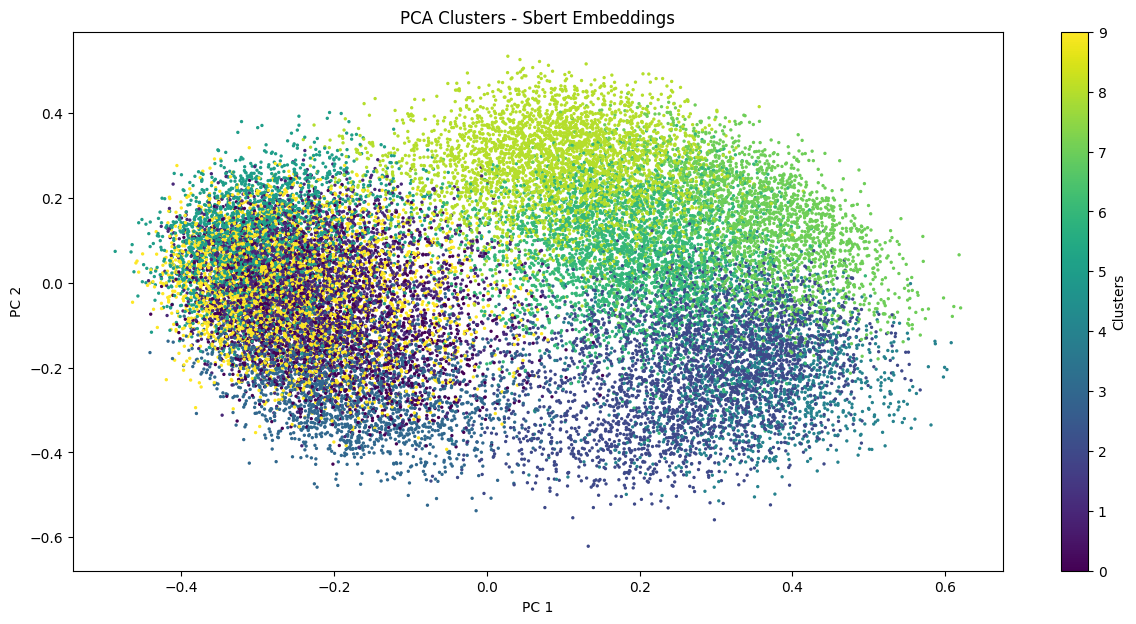

In [16]:
import matplotlib.pyplot as plt

X_matrix = embeddings
mu = X_matrix.mean(axis=0)
Z = X_matrix - mu

cov_matrix = np.cov(Z,rowvar=False)

eigvals, eigvecs = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:,idx]
pca_projection = Z @ eigvecs[:,:2]

df['pca_1'] = pca_projection[:,0]
df['pca_2'] = pca_projection[:,1]

fig, ax = plt.subplots(figsize=(15,7))
scatter = ax.scatter(df['pca_1'],df['pca_2'],c=df['kmeans_clusters'],s=2)
plt.colorbar(scatter,ax=ax,label='Clusters')
ax.set_title('PCA Clusters - Sbert Embeddings',fontsize=12)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.savefig('pca_clusters_nithya_sbert.png',dpi=150)
files.download('pca_clusters_nithya_sbert.png')
plt.show()

In [17]:
print(df.head())

         id           submitter  \
0  704.1274      Dev Rajnarayan   
1  704.1394  Tarik Had\v{z}i\'c   
2  704.2010   Juliana Bernardes   
3  704.2668        Alex Smola J   
4  704.3433   Tshilidzi Marwala   

                                             authors  \
0             David H. Wolpert and Dev G. Rajnarayan   
1  Tarik Hadzic, Rune Moller Jensen, Henrik Reif ...   
2  Juliana S Bernardes, Alberto Davila, Vitor San...   
3  Le Song, Alex Smola, Arthur Gretton, Karsten B...   
4            Tshilidzi Marwala and Bodie Crossingham   

                                               title             comments  \
0   Parametric Learning and Monte Carlo Optimization                  NaN   
1  Calculating Valid Domains for BDD-Based Intera...                  NaN   
2  A study of structural properties on profiles HMMs   6 pages, 7 figures   
3  Supervised Feature Selection via Dependence Es...              9 pages   
4                     Bayesian approach to rough set  20 pages, 3 f

In [18]:
print(df['period'].value_counts().sort_index())

period
2007-2011     1268
2012-2016     5542
2017-2021    20311
Name: count, dtype: int64


In [19]:
print("Oldest Year :",df['year'].min())
print("Latest Year :",df['year'].max())
print("Total num of papers :",len(df))

Oldest Year : 2007
Latest Year : 2021
Total num of papers : 27121


# Experimenting with another model - Specter

In [20]:
model_specter = SentenceTransformer('sentence-transformers/allenai-specter')  #using specter model to compare with MiniLM

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/331 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [21]:
similarity_score_comparision = model_specter.encode([df['abstract'].iloc[0], df['abstract'].iloc[1]],convert_to_numpy=True)
specter_similarity_score = manual_cossim(similarity_score_comparision[0],similarity_score_comparision[1])
print(f"MiniLM similarity score : {similarity_score :}")
print(f"Specter similarity score : {specter_similarity_score :}")

MiniLM similarity score : 0.2500593364238739
Specter similarity score : 0.7725767493247986


In [22]:
specter_model_embeddings = model_specter.encode(df['abstract'].tolist(),show_progress_bar=True)
print(specter_model_embeddings.shape)

Batches:   0%|          | 0/848 [00:00<?, ?it/s]

(27121, 768)


In [23]:
np.save('specter_model_embeddings_nithya.npy',specter_model_embeddings)
files.download('specter_model_embeddings_nithya.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from sklearn.metrics import silhouette_score

k_means_test = KMeans(n_clusters=10,random_state=33)

minilm_label = k_means_test.fit_predict(embeddings)
minilm_similarity_score = silhouette_score(embeddings,minilm_label,metric='cosine',sample_size=3000)

specter_label = k_means_test.fit_predict(specter_model_embeddings)
specter_similarity_score = silhouette_score(specter_model_embeddings,specter_label,metric='cosine',sample_size=3000)

print(f"MiniLM silhouette score : {minilm_similarity_score:}")
print(f"Specter silhouette score : {specter_similarity_score:}")

MiniLM silhouette score : 0.058148618787527084
Specter silhouette score : 0.09207513183355331


In [25]:
# trying different k values

k_vals = []
for v in range(5,20):
    k_vals.append(v)

minilm_similarity_score_k = []
specter_similarity_score_k = []

for k in k_vals:
    k_means = KMeans(n_clusters=k,random_state=33)
    minilm_labels_k = k_means.fit_predict(embeddings)
    minilm_similarity_score_k.append(silhouette_score(embeddings,minilm_labels_k,metric='cosine',sample_size=3000))
    specter_labels_k = k_means.fit_predict(specter_model_embeddings)
    specter_similarity_score_k.append(silhouette_score(specter_model_embeddings,specter_labels_k,metric='cosine',sample_size=3000))
    print(f"k = {k}  MiniLM = {minilm_similarity_score_k[-1]:.4f}  Specter = {specter_similarity_score_k[-1]:.4f}")

k = 5  MiniLM = 0.0627  Specter = 0.0901
k = 6  MiniLM = 0.0549  Specter = 0.0947
k = 7  MiniLM = 0.0510  Specter = 0.0856
k = 8  MiniLM = 0.0576  Specter = 0.0915
k = 9  MiniLM = 0.0588  Specter = 0.0932
k = 10  MiniLM = 0.0601  Specter = 0.0973
k = 11  MiniLM = 0.0584  Specter = 0.0934
k = 12  MiniLM = 0.0525  Specter = 0.0993
k = 13  MiniLM = 0.0604  Specter = 0.0942
k = 14  MiniLM = 0.0603  Specter = 0.0898
k = 15  MiniLM = 0.0579  Specter = 0.0950
k = 16  MiniLM = 0.0584  Specter = 0.0964
k = 17  MiniLM = 0.0634  Specter = 0.0924
k = 18  MiniLM = 0.0681  Specter = 0.0936
k = 19  MiniLM = 0.0635  Specter = 0.0933


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

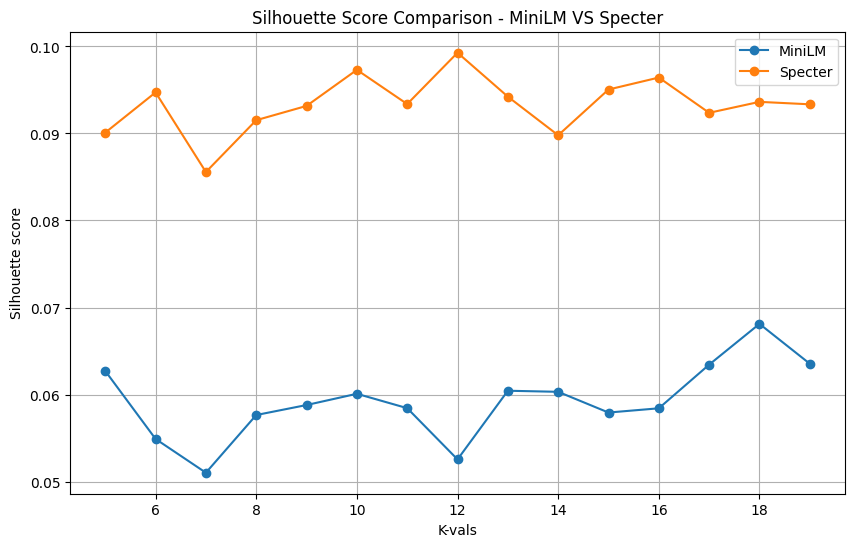

In [26]:
# plotting the silhouette scores

plt.figure(figsize=(10,6))
plt.plot(k_vals,minilm_similarity_score_k,marker='o',label='MiniLM')
plt.plot(k_vals,specter_similarity_score_k,marker='o',label='Specter')
plt.xlabel('K-vals')
plt.ylabel('Silhouette score')  # higher the better
plt.title('Silhouette Score Comparison - MiniLM VS Specter')
plt.legend()
plt.grid(True)
plt.savefig('silhouette_comparison_minilm_vs_specter.png',dpi=150)
files.download('silhouette_comparison_minilm_vs_specter.png')
plt.show()

# Using one more model MPNet for comparision


In [27]:
model_mpnet = SentenceTransformer('all-mpnet-base-v2')  # experimenting with another model MPNet

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [28]:
mpnet_model_embeddings = model_mpnet.encode(df['abstract'].tolist(),show_progress_bar=True)
print(mpnet_model_embeddings.shape)
np.save('mpnet_model_embeddings_nithya.npy',mpnet_model_embeddings)
files.download('mpnet_model_embeddings_nithya.npy')

Batches:   0%|          | 0/848 [00:00<?, ?it/s]

(27121, 768)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
embeddings_dict = {'MiniLM':embeddings,'MPNet':mpnet_model_embeddings,'Specter':specter_model_embeddings} # storing all 3 model's embeddings as a dict for easier access
for model_name,embdngs in embeddings_dict.items():
    print(model_name,embdngs.shape) # to verify if all 3 gives same num of rows like it should

MiniLM (27121, 384)
MPNet (27121, 768)
Specter (27121, 768)


In [30]:
print("Silhouette Scores for all 3 models :")  # comparing all 3 models
for model_name,embdngs in embeddings_dict.items():
    k_means = KMeans(n_clusters=10,random_state=33)
    labels = k_means.fit_predict(embdngs)
    silh_score = silhouette_score(embdngs,labels,metric='cosine',sample_size=3000)
    print(f"{model_name} : {silh_score:.4f}")

Silhouette Scores for all 3 models :
MiniLM : 0.0582
MPNet : 0.0731
Specter : 0.0953


# Can the models tell the time periods apart?

In [31]:
from sklearn.preprocessing import LabelEncoder

period_nums = LabelEncoder().fit_transform(df['period'])
for model_name,embdngs in embeddings_dict.items():
    silh_score = silhouette_score(embdngs,period_nums,metric='cosine',sample_size=9000)
    print(f"{model_name} : {silh_score:.4f}")

MiniLM : 0.0532
MPNet : 0.0575
Specter : 0.0181


In [32]:
# to save silhouette scores

silhouette_results = {}
for model_name,embdngs in embeddings_dict.items():
    silh_score = silhouette_score(embdngs,period_nums,metric='cosine',sample_size=9000)
    silhouette_results[model_name] = round(float(silh_score),6)
pd.DataFrame([silhouette_results]).to_csv('sbert_silhouette_scores_nithya.csv',index=False)
files.download('sbert_silhouette_scores_nithya.csv')

print(silhouette_results)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{'MiniLM': 0.054125, 'MPNet': 0.055926, 'Specter': 0.017233}


# PCA

In [33]:
X_spec = specter_model_embeddings
mu_spec = X_spec.mean(axis=0)
Z_spec = X_spec - mu_spec

R_spec = np.cov(Z_spec,rowvar=False)
evals_spec, evecs_spec = np.linalg.eigh(R_spec)

idx_spec = np.argsort(evals_spec)[::-1]
evecs_spec = evecs_spec[:,idx_spec]

pca_coords = Z_spec @ evecs_spec[:,:2]

df['pca_x'] = pca_coords[:,0]
df['pca_y'] = pca_coords[:,1]

total_var = np.sum(evals_spec)
print(f"PC 1 : {(evals_spec[idx_spec[0]]/total_var)*100:.2f}%")
print(f"PC 2 : {(evals_spec[idx_spec[1]]/total_var)*100:.2f}%")

PC 1 : 12.22%
PC 2 : 6.10%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

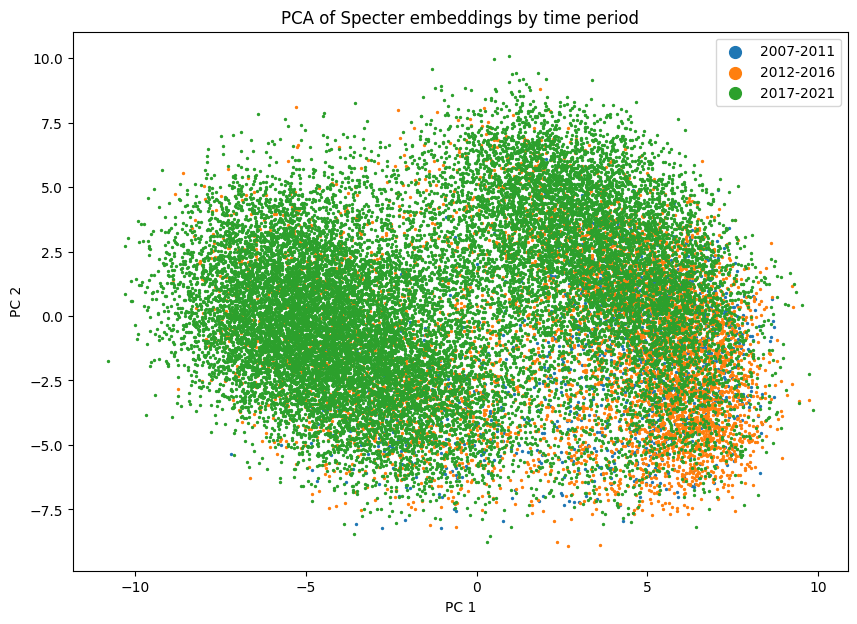

In [34]:
fig,ax = plt.subplots(figsize=(10,7))

for p in period_order:
    mask = df['period'] == p
    ax.scatter(df.loc[mask,'pca_x'],df.loc[mask,'pca_y'],label=p,s=2)

ax.set_title('PCA of Specter embeddings by time period')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(markerscale=6)
plt.savefig('pca_by_period_nithya.png',dpi=150)
files.download('pca_by_period_nithya.png')
plt.show()

In [35]:
# Export PCA coordinates for integration notebook

pca_export = df[['period','pca_x','pca_y']].copy()
pca_export.to_csv('sbert_pca_coords_nithya.csv',index=False)
files.download('sbert_pca_coords_nithya.csv')
print(pca_export.shape)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(27121, 3)


# Visualising the Trajectory of the field

In [36]:
centroid_x_coord = []
centroid_y_coord = []

for p in period_order:
    mask = df['period'] == p
    mean_x = df.loc[mask,'pca_x'].mean()
    mean_y = df.loc[mask,'pca_y'].mean()
    centroid_x_coord.append(mean_x)
    centroid_y_coord.append(mean_y)
    print(f"Centroid for {p} : ({mean_x:.4f},{mean_y:.4f})")

Centroid for 2007-2011 : (3.9855,-1.8378)
Centroid for 2012-2016 : (2.7400,-1.2111)
Centroid for 2017-2021 : (-0.9964,0.4452)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

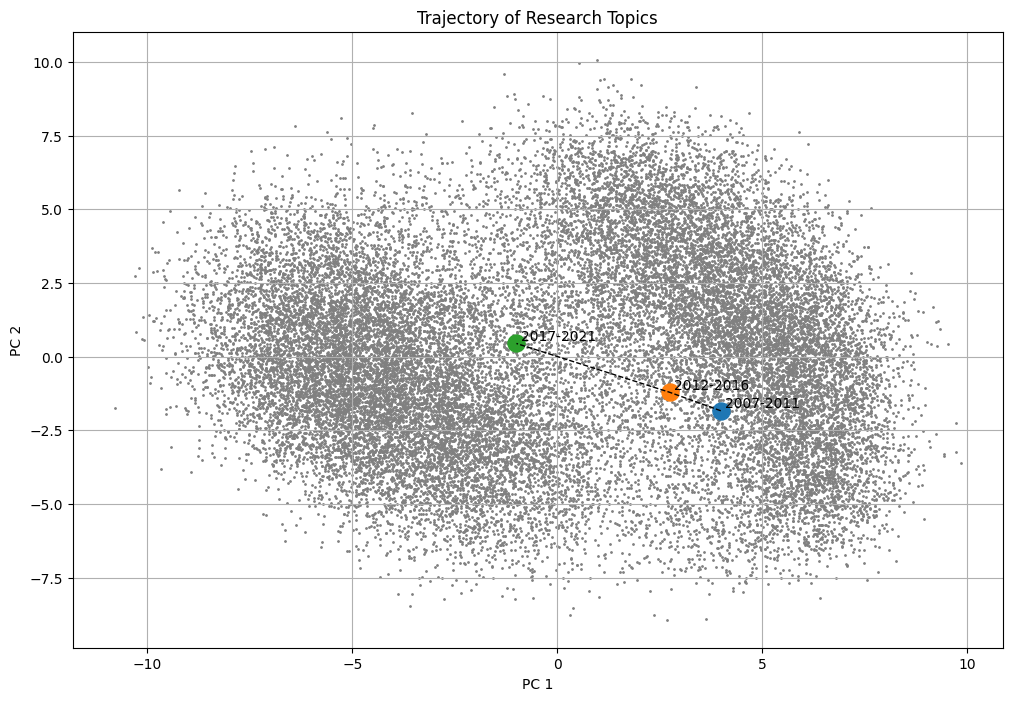

In [39]:
plt.figure(figsize=(12,8))
plt.scatter(df['pca_x'],df['pca_y'],s=1,color='grey')
plt.plot(centroid_x_coord,centroid_y_coord,'k--',linewidth=1) # dashed line connecting centroids to show change

for i, p in enumerate(period_order):
    plt.scatter(centroid_x_coord[i],centroid_y_coord[i],s=150)
    plt.text(centroid_x_coord[i]+0.1,centroid_y_coord[i]+0.1,p,fontsize=10,color='black')

plt.title('Trajectory of Research Topics')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True)
plt.savefig('trajectory_topics_nithya.png',dpi=150)
files.download('trajectory_topics_nithya.png')
plt.show()

# By how much the field changed between each period


In [40]:
space_row = []

for model_name,embdngs in embeddings_dict.items():
    centroids = {}
    for p in period_order:
        mask = df['period'] == p
        centroids[p] = embdngs[mask.values].mean(axis=0)
    for i in range(len(period_order)-1):
        p1 = period_order[i]
        p2 = period_order[i+1]
        cos_sim = manual_cossim(centroids[p1],centroids[p2])
        space_row.append({'model':model_name,'period from':p1,'period to':p2,'distance':round(1-cos_sim,4)})

space_table = pd.DataFrame(space_row)
print(space_table)

     model period from  period to  distance
0   MiniLM   2007-2011  2012-2016    0.0461
1   MiniLM   2012-2016  2017-2021    0.1221
2    MPNet   2007-2011  2012-2016    0.0500
3    MPNet   2012-2016  2017-2021    0.1388
4  Specter   2007-2011  2012-2016    0.0055
5  Specter   2012-2016  2017-2021    0.0298


In [41]:
# to save model's centroid distances

# MiniLM
dist_minilm = space_table[space_table['model']=='MiniLM']['distance'].tolist()
np.save('sbert_minilm_centroid_distances_nithya.npy',dist_minilm)
files.download('sbert_minilm_centroid_distances_nithya.npy')
print(f"MiniLM distances saved : {dist_minilm}")

# MPNet
dist_mpnet = space_table[space_table['model']=='MPNet']['distance'].tolist()
np.save('sbert_mpnet_centroid_distances_nithya.npy',dist_mpnet)
files.download('sbert_mpnet_centroid_distances_nithya.npy')
print(f"MPNet distances saved : {dist_mpnet}")

# Specter
dist_specter = space_table[space_table['model']=='Specter']['distance'].tolist()
np.save('sbert_specter_centroid_distances_nithya.npy',dist_specter)
files.download('sbert_specter_centroid_distances_nithya.npy')
print(f"Specter distances saved : {dist_specter}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MiniLM distances saved : [0.04610000178217888, 0.12210000306367874]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MPNet distances saved : [0.05000000074505806, 0.1387999951839447]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Specter distances saved : [0.005499999970197678, 0.02979999966919422]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

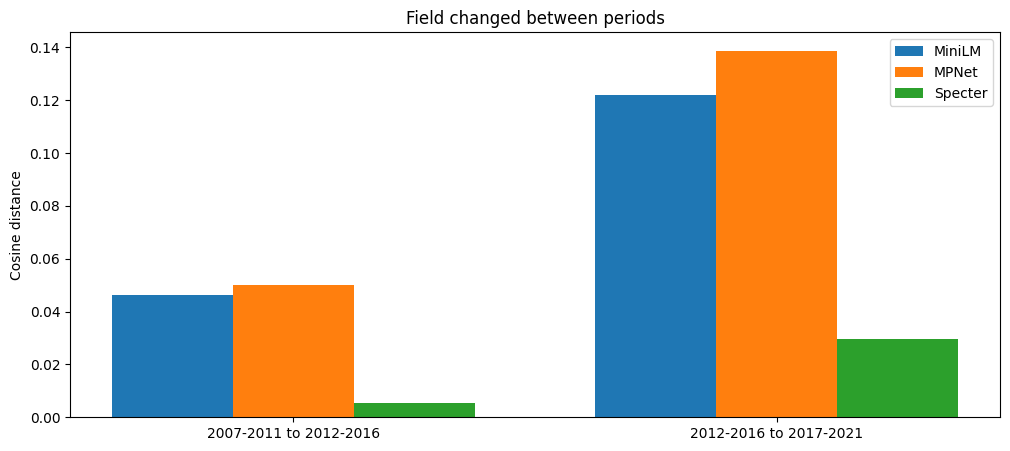

In [42]:
transitions = [f"{period_order[i]} to {period_order[i+1]}" for i in range(len(period_order) - 1)]

fig, ax = plt.subplots(figsize=(12,5))
bar_width = 0.25
x = np.arange(len(transitions))

for i,model_name in enumerate(['MiniLM','MPNet','Specter']):
    rows = space_table[space_table['model'] == model_name]
    ax.bar(x+i*bar_width,rows['distance'].tolist(),bar_width,label=model_name)

ax.set_xticks(x+bar_width)
ax.set_xticklabels(transitions)
ax.set_ylabel('Cosine distance')
ax.set_title('Field changed between periods')
ax.legend()
plt.savefig('field_changed_between_periods_nithya.png',dpi=150)
files.download('field_changed_between_periods_nithya.png')
plt.show()

# Analysing how communication and meaning has changed

In [43]:
def find_pprs_for_term(description,period,top_k=8):
    term_emb = model_specter.encode([description],convert_to_numpy=True)[0]
    mask = df['period'] == period
    period_df = df[mask].reset_index(drop=True)
    period_embdngs = specter_model_embeddings[mask.values]
    scores = []
    for pe in period_embdngs:
        cos_sim = manual_cossim(term_emb,pe)
        scores.append(cos_sim)
    scores = np.array(scores)
    top_idx = scores.argsort()[-top_k:][::-1]
    results = period_df.iloc[top_idx][['year','title']].copy()
    results['similarity_score'] = scores[top_idx].round(3)
    return results.reset_index(drop=True)

In [44]:
print("'language models' across periods:\n")

for p in period_order:
    print(f"{[p]} :")
    r = find_pprs_for_term('a model that predicts and generates natural language text',p)
    print(r[['year','title']].to_string(index=False))
    print()

'language models' across periods:

['2007-2011'] :
 year                                                                                              title
 2007                                                                          In memoriam Maurice Gross
 2011                                        Acquiring Correct Knowledge for Natural Language Generation
 2009                    Induction of Word and Phrase Alignments for Automatic Document\n  Summarization
 2008 Methods to integrate a language model with semantic information for a\n  word prediction component
 2011                   Object-oriented semantics of English in natural language understanding\n  system
 2011                                               A Probabilistic Approach to Pronunciation by Analogy
 2007                                        Bootstrapping Deep Lexical Resources: Resources for Courses
 2008           Computational Representation of Linguistic Structures using\n  Domain-Specific Languages

['2

In [45]:
# trying another one

print("'neural network' across periods:\n")

for p in period_order:
    print(f"{[p]} :")
    r = find_pprs_for_term('deep neural network architecture',p)
    print(r[['year','title']].to_string(index=False))
    print()

'neural network' across periods:

['2007-2011'] :
 year                                                                                          title
 2008                 Prediction of Platinum Prices Using Dynamically Weighted Mixture of\n  Experts
 2010                                                                       The Attentive Perceptron
 2011                   Adding noise to the input of a model trained with a regularized\n  objective
 2011                Analysis and Extension of Arc-Cosine Kernels for Large Margin\n  Classification
 2007                                                                  Tests of Machine Intelligence
 2007 Comparing Robustness of Pairwise and Multiclass Neural-Network Systems\n  for Face Recognition
 2008                                                     From Data Topology to a Modular Classifier
 2008                                         Introduction to Relational Networks for Classification

['2012-2016'] :
 year                   

# Analysing how focus has changed


In [46]:
# measuring average distance within each period

diversity_rows_period = []

for model_name,embdngs in embeddings_dict.items():
    for p in period_order:
        mask = df['period'] == p
        period_embdngs = embdngs[mask.values]
        centroid = period_embdngs.mean(axis=0)
        if len(period_embdngs)>1000:
            choice = np.random.choice(len(period_embdngs),1000,replace=False)
            sample_embdngs = period_embdngs[choice]
        else:
            sample_embdngs = period_embdngs
        dist = []
        for se in sample_embdngs:
            cos_sim = manual_cossim(se,centroid)
            dist.append(1 - cos_sim)
        avg_diversity = np.mean(dist)
        diversity_rows_period.append({'model': model_name,'period': p,'diversity_score': round(avg_diversity,4)})

diversity_table = pd.DataFrame(diversity_rows_period)
print(diversity_table)

     model     period  diversity_score
0   MiniLM  2007-2011           0.5960
1   MiniLM  2012-2016           0.5729
2   MiniLM  2017-2021           0.4910
3    MPNet  2007-2011           0.5743
4    MPNet  2012-2016           0.5481
5    MPNet  2017-2021           0.4832
6  Specter  2007-2011           0.1790
7  Specter  2012-2016           0.1807
8  Specter  2017-2021           0.1867


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

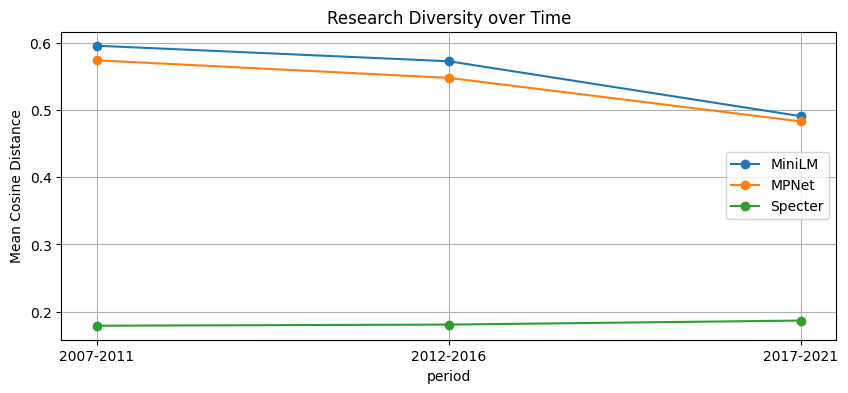

In [47]:
fig,ax = plt.subplots(figsize=(10,4))

for model_name in ['MiniLM','MPNet','Specter']:
    rows = diversity_table[diversity_table['model'] == model_name]
    rows = rows.set_index('period').reindex(period_order)
    ax.plot(period_order,rows['diversity_score'].values,marker='o',label=model_name)

ax.set_xlabel('period')
ax.set_ylabel('Mean Cosine Distance')
ax.set_title('Research Diversity over Time')
ax.legend()
ax.grid(True)
plt.savefig('diversity_over_time_nithya.png',dpi=150)
files.download('diversity_over_time_nithya.png')
plt.show()

# Analysing how framing has changed

In [48]:
eg_sentence = {'state-of-the-art': 'Our approach achieves state-of-the-art results on standard benchmarks',
             'theoretical': 'We provide a formal analysis of properties and establish theoretical results',
             'real-world appln': 'We demonstrate the practical application of our framework in a real-world scenario',
             'new dataset': 'We present a novel, large-scale annotated dataset',
             'scaling up': 'We scale our model to billions of parameters',
             'interpretability': 'We analyse what the model has learned internally'}

names = list(eg_sentence.keys())
framing_embdngs = model_specter.encode(list(eg_sentence.values()),convert_to_numpy=True)
print(framing_embdngs.shape)

(6, 768)


In [49]:
results = {}

for p in period_order:
    mask = df['period'] == p
    period_embdngs = specter_model_embeddings[mask.values]
    if len(period_embdngs)>800:
        choice = np.random.choice(len(period_embdngs),800,replace=False)
        p_embdngs = period_embdngs[choice]
    else:
        p_embdngs = period_embdngs
    period_scores = []
    for framing_emb in framing_embdngs:
        sims = []
        for p_emb in p_embdngs:
            sims.append(manual_cossim(framing_emb,p_emb))
        period_scores.append(np.mean(sims))
    results[p] = np.array(period_scores)

result_table = pd.DataFrame(results,index=names)
print(result_table.round(4))

                  2007-2011  2012-2016  2017-2021
state-of-the-art     0.6452     0.6538     0.6524
theoretical          0.7167     0.7105     0.6462
real-world appln     0.7049     0.7098     0.6794
new dataset          0.7271     0.7368     0.7248
scaling up           0.7152     0.7206     0.6818
interpretability     0.6519     0.6657     0.6571


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

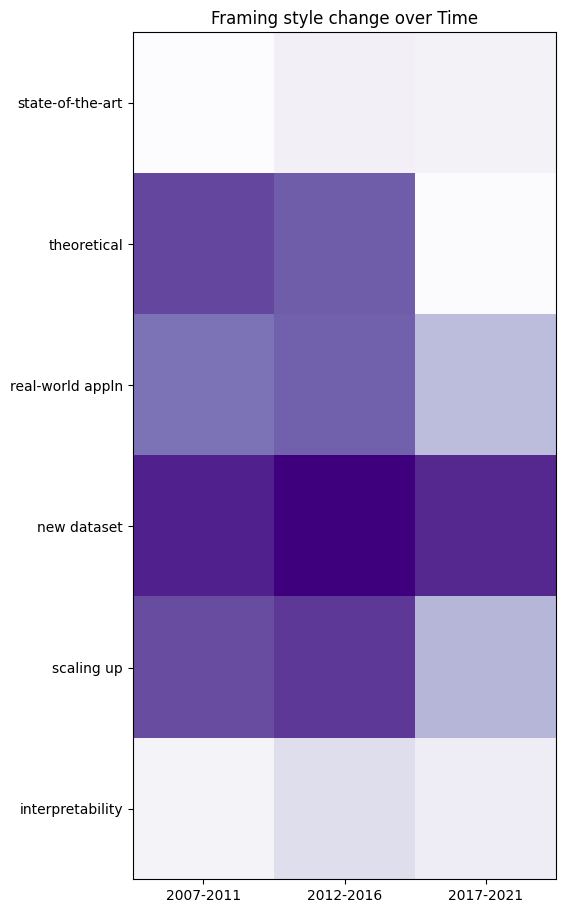

In [51]:
fig,ax = plt.subplots(figsize=(11,11))

image = ax.imshow(result_table.values,cmap='Purples')

ax.set_xticks(range(len(period_order)))
ax.set_xticklabels(period_order)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)

ax.set_title('Framing style change over Time')
plt.savefig('framing_style_heatmap_nithya.png',dpi=150)
files.download('framing_style_heatmap_nithya.png')
plt.show()

In [52]:
# Exporting framing heatmap data for final integration
result_table.to_csv('sbert_framing_heatmap_nithya.csv')
files.download('sbert_framing_heatmap_nithya.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>